# Enhancing Financial Market Predictions with Financial News Sentiment

## Project topic

This project investigates whether financial news sentiment is related to short-term stock market returns for selected technology companies.

The analysis combines two independent data sources:

1. **Financial news headlines** from `analyst_ratings_processed.csv`
2. **Historical stock market prices** from `tech_stock_prices_2020_to_today.csv`

The project follows a technical-report structure: problem formulation, data cleaning, sentiment engineering, data integration, exploratory analysis, statistical testing, predictive modeling, interpretation, and limitations.

## Research question

Can daily financial-news sentiment help explain or predict short-term stock returns for major technology companies?

## Objectives

- Clean and validate two independent datasets.
- Transform unstructured headlines into daily sentiment features.
- Merge news sentiment with stock-price observations.
- Test whether sentiment is associated with same-day and next-day stock returns.
- Build baseline predictive models for next-day returns.

We will focus on three companies that are present in both datasets and have sufficient news coverage:

- **AAPL** — Apple
- **TSLA** — Tesla
- **NVDA** — Nvidia


## Mathematical background and statistical framework

### Daily return

Daily return measures the relative change in closing price between two consecutive trading days:

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

where $P_t$ is the closing price on day $t$ and $P_{t-1}$ is the closing price on the previous trading day.

The modeling target is the next trading day's return:

$$
y_t = R_{t+1}
$$

Using $R_{t+1}$ helps reduce look-ahead bias because the model uses information available on day $t$ to predict the following trading day.

### Sentiment score

Each headline is converted into a numerical sentiment score:

$$
S_i \in [-1, 1]
$$

where negative values indicate negative sentiment, values close to zero indicate neutral sentiment, and positive values indicate positive sentiment.

Daily average sentiment is calculated as:

$$
\bar{S}_t = \frac{1}{n_t}\sum_{i=1}^{n_t} S_{i,t}
$$

where $n_t$ is the number of news headlines for a company on day $t$.

### Pearson correlation

The linear relationship between daily sentiment and returns is tested with Pearson's correlation coefficient:

$$
r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

The null hypothesis is that there is no linear relationship between sentiment and returns.

### Welch's t-test

The notebook compares returns on positive-sentiment days and negative-sentiment days using Welch's t-test, which does not assume equal variance:

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$

### Regression evaluation metrics

The predictive models are evaluated with standard regression metrics:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y_i})^2
$$

$$
RMSE = \sqrt{MSE}
$$

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y_i}|
$$

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

These metrics measure prediction error and explanatory power. In financial-return prediction, even small improvements can be meaningful, but results must be interpreted cautiously because market data is noisy and non-stationary.


In [220]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 1. Data loading

The notebook expects the following files to be available in the same folder as the notebook:

- `analyst_ratings_processed.csv`
- `tech_stock_prices_2020_to_today.csv`

If the notebook is executed in the original working environment, it will also try `/mnt/data`.

In [221]:
DATA_DIR = Path(".")
if not (DATA_DIR / "analyst_ratings_processed.csv").exists():
    DATA_DIR = Path("/mnt/data")

NEWS_PATH = DATA_DIR / "analyst_ratings_processed.csv"
STOCK_PATH = DATA_DIR / "tech_stock_prices_2020_to_today.csv"

print("News dataset path:", NEWS_PATH)
print("Stock dataset path:", STOCK_PATH)

News dataset path: analyst_ratings_processed.csv
Stock dataset path: tech_stock_prices_2020_to_today.csv


In [222]:
news_raw = pd.read_csv(
    NEWS_PATH,
    usecols=["title", "date", "stock"]
)

stock_raw = pd.read_csv(STOCK_PATH)

print("News shape:", news_raw.shape)
print("Stock shape:", stock_raw.shape)

display(news_raw.head())
display(stock_raw.head())

News shape: (1400466, 3)
Stock shape: (23160, 18)


,title,date,stock
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00-04:00,A
2,71 Biggest Movers From Friday,2020-05-26 04:30:00-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00-04:00,A


,index,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Dividends,Stock Splits,P/E Ratio,Market Cap,Price/Sales Ratio,Price/Book Ratio,Dividend Yield,Daily Return,20-Day MA
0,0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.960464,135480400,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.251122,146322800,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.826859,118387200,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.484352,108872000,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2020-01-08,74.290001,76.110001,74.290001,75.797501,73.650352,132079200,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Initial data inspection

In [223]:
print("News columns:")
print(news_raw.columns)

print("\nStock columns:")
print(stock_raw.columns)

print("\nAvailable stock tickers in stock dataset:")
print(stock_raw["Ticker"].unique())

print("\nNews records for stock tickers available in the stock dataset:")
available_stock_tickers = stock_raw["Ticker"].unique()
display(news_raw[news_raw["stock"].isin(available_stock_tickers)]["stock"].value_counts())

News columns:
Index(['title', 'date', 'stock'], dtype='object')

Stock columns:
Index(['index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Ticker', 'Dividends', 'Stock Splits', 'P/E Ratio', 'Market Cap',
       'Price/Sales Ratio', 'Price/Book Ratio', 'Dividend Yield',
       'Daily Return', '20-Day MA'],
      dtype='object')

Available stock tickers in stock dataset:
['AAPL' 'MSFT' 'AMZN' 'GOOGL' 'TSLA' 'META' 'NVDA' 'IBM' 'ORCL' 'INTC']

News records for stock tickers available in the stock dataset:


stock
NVDA     3133
ORCL     2695
TSLA     1930
GOOGL    1585
IBM      1083
AAPL      469
AMZN      330
INTC       10
Name: count, dtype: int64

## 3. Company selection

We will choose 3 companies. The selected companies are:

- AAPL
- TSLA
- NVDA

These companies are present in both datasets and have enough financial news records for some analysis.

In [224]:
selected_tickers = ["AAPL", "TSLA", "NVDA"]

news = news_raw[news_raw["stock"].isin(selected_tickers)].copy()
stock = stock_raw[stock_raw["Ticker"].isin(selected_tickers)].copy()

print("Filtered news shape:", news.shape)
print("Filtered stock shape:", stock.shape)

display(news["stock"].value_counts())
display(stock["Ticker"].value_counts())

Filtered news shape: (5532, 3)
Filtered stock shape: (6948, 18)


stock
NVDA    3133
TSLA    1930
AAPL     469
Name: count, dtype: int64

Ticker
AAPL    2316
TSLA    2316
NVDA    2316
Name: count, dtype: int64

## 4. Data cleaning

### News dataset cleaning

Required steps:

1. Remove missing titles, dates, and tickers.
2. Convert timestamps to UTC datetime.
3. Extract the calendar date for daily merging.
4. Clean text for sentiment analysis.

### Stock dataset cleaning

Required steps:

1. Convert dates to datetime.
2. Sort by company and date.
3. Ensure numerical columns have correct types.
4. Calculate daily returns if the existing column is incomplete.

In [225]:
news = news.dropna(subset=["title", "date", "stock"]).copy()

news["date"] = pd.to_datetime(news["date"], utc=True, errors="coerce")
news = news.dropna(subset=["date"]).copy()

news["Date"] = news["date"].dt.date
news["Date"] = pd.to_datetime(news["Date"])

news["title_clean"] = (
    news["title"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-zA-Z\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

display(news.head())
print(news.info())

,title,date,stock,Date,title_clean
3666,Tech Stocks And FAANGS Strong Again To Start D...,2020-06-10 15:33:00+00:00,AAPL,2020-06-10,tech stocks and faangs strong again to start d...
3667,10 Biggest Price Target Changes For Wednesday,2020-06-10 12:14:00+00:00,AAPL,2020-06-10,biggest price target changes for wednesday
3668,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",2020-06-10 11:53:00+00:00,AAPL,2020-06-10,benzinga pro s top stocks to watch for wed jun...
3669,"Deutsche Bank Maintains Buy on Apple, Raises P...",2020-06-10 11:19:00+00:00,AAPL,2020-06-10,deutsche bank maintains buy on apple raises pr...
3670,Apple To Let Users Trade In Their Mac Computer...,2020-06-10 10:27:00+00:00,AAPL,2020-06-10,apple to let users trade in their mac computer...


<class 'pandas.core.frame.DataFrame'>
Index: 5532 entries, 3666 to 1250208
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   title        5532 non-null   object             
 1   date         5532 non-null   datetime64[ns, UTC]
 2   stock        5532 non-null   object             
 3   Date         5532 non-null   datetime64[ns]     
 4   title_clean  5532 non-null   object             
dtypes: datetime64[ns, UTC](1), datetime64[ns](1), object(3)
memory usage: 259.3+ KB
None


In [226]:
stock["Date"] = pd.to_datetime(stock["Date"], errors="coerce")
stock = stock.dropna(subset=["Date", "Ticker", "Close"]).copy()

numeric_columns = [
    "Open", "High", "Low", "Close", "Adj Close", "Volume",
    "Daily Return", "20-Day MA"
]

for column in numeric_columns:
    if column in stock.columns:
        stock[column] = pd.to_numeric(stock[column], errors="coerce")

stock = stock.sort_values(["Ticker", "Date"])

stock["calculated_return"] = stock.groupby("Ticker")["Close"].pct_change()

if "Daily Return" in stock.columns:
    stock["Daily Return"] = stock["Daily Return"].fillna(stock["calculated_return"])
else:
    stock["Daily Return"] = stock["calculated_return"]

stock["return_next_day"] = stock.groupby("Ticker")["Daily Return"].shift(-1)
stock["close_lag_1"] = stock.groupby("Ticker")["Close"].shift(1)
stock["volume_change"] = stock.groupby("Ticker")["Volume"].pct_change()

display(stock.head())
display(stock[["Ticker", "Date", "Close", "Daily Return", "return_next_day"]].head(10))

,index,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Dividends,Stock Splits,P/E Ratio,Market Cap,Price/Sales Ratio,Price/Book Ratio,Dividend Yield,Daily Return,20-Day MA,calculated_return,return_next_day,close_lag_1,volume_change
0,0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.960464,135480400,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
11580,11580,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.960464,135480400,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,0.000000,NaN,0.000000,-0.009722,75.087502,0.000000
1,1,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.251122,146322800,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,-0.009722,NaN,-0.009722,-0.009722,75.087502,0.080029
11581,11581,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.251122,146322800,AAPL,0.0,0.0,32.913242,3.287735e+12,8.526217,49.347332,0.0047,-0.009722,NaN,0.000000,0.007968,74.357498,0.000000
2,2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.826859,118387200,AAPL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.007968,NaN,0.007968,0.007968,74.357498,-0.190918


,Ticker,Date,Close,Daily Return,return_next_day
0,AAPL,2020-01-02,75.087502,NaN,0.000000
11580,AAPL,2020-01-02,75.087502,0.000000,-0.009722
1,AAPL,2020-01-03,74.357498,-0.009722,-0.009722
11581,AAPL,2020-01-03,74.357498,-0.009722,0.007968
2,AAPL,2020-01-06,74.949997,0.007968,0.007968
11582,AAPL,2020-01-06,74.949997,0.007968,-0.004703
3,AAPL,2020-01-07,74.597504,-0.004703,-0.004703
11583,AAPL,2020-01-07,74.597504,-0.004703,0.016086
4,AAPL,2020-01-08,75.797501,0.016086,0.016086
11584,AAPL,2020-01-08,75.797501,0.016086,0.021241


## 5. Sentiment analysis

A finance-oriented lexicon-based sentiment function is used. This avoids external API dependencies and makes the notebook reproducible.

The method is intentionally simple and transparent:

- positive finance words increase the sentiment score
- negative finance words decrease the sentiment score
- the final score is normalized to the range `[-1, 1]`

This is not as advanced as transformer-based NLP models, but it is appropriate for a data-analysis project and easy to explain mathematically.

In [227]:
positive_words = {
    "gain", "gains", "gained", "rise", "rises", "rising", "rose", "up", "higher",
    "surge", "surges", "surged", "jump", "jumps", "jumped", "beat", "beats",
    "strong", "growth", "grow", "grows", "grew", "profit", "profits", "profitable",
    "upgrade", "upgraded", "buy", "bullish", "positive", "outperform", "record",
    "tops", "boost", "boosts", "raised", "raises", "increase", "increases",
    "expansion", "rally", "rallies", "recover", "recovery", "optimistic"
}

negative_words = {
    "loss", "losses", "fall", "falls", "falling", "fell", "down", "lower",
    "drop", "drops", "dropped", "decline", "declines", "declined", "miss",
    "misses", "missed", "weak", "risk", "risks", "risky", "downgrade",
    "downgraded", "sell", "bearish", "negative", "underperform", "cut",
    "cuts", "recession", "crisis", "lawsuit", "investigation", "warning",
    "warns", "warned", "slump", "slumps", "plunge", "plunges", "plunged",
    "concern", "concerns", "volatile", "volatility", "pressure"
}

def finance_sentiment_score(text):
    tokens = re.findall(r"[a-zA-Z]+", str(text).lower())
    if not tokens:
        return 0.0

    positive_count = sum(token in positive_words for token in tokens)
    negative_count = sum(token in negative_words for token in tokens)

    raw_score = positive_count - negative_count
    normalizer = positive_count + negative_count

    if normalizer == 0:
        return 0.0

    return raw_score / normalizer

news["sentiment"] = news["title_clean"].apply(finance_sentiment_score)

display(news[["title", "stock", "Date", "sentiment"]].head(10))
display(news["sentiment"].describe())

,title,stock,Date,sentiment
3666,Tech Stocks And FAANGS Strong Again To Start D...,AAPL,2020-06-10,1.0
3667,10 Biggest Price Target Changes For Wednesday,AAPL,2020-06-10,0.0
3668,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",AAPL,2020-06-10,0.0
3669,"Deutsche Bank Maintains Buy on Apple, Raises P...",AAPL,2020-06-10,1.0
3670,Apple To Let Users Trade In Their Mac Computer...,AAPL,2020-06-10,0.0
3671,Big Tech Reaches New Record Heights At The Sto...,AAPL,2020-06-10,1.0
3672,Why Apple's Stock Is Trading Higher Today,AAPL,2020-06-09,1.0
3673,Apple Could Announce In-House Chips For Macs A...,AAPL,2020-06-09,0.0
3674,Apple shares are trading higher despite market...,AAPL,2020-06-09,1.0
3675,"Sonos Shares Spike To Session High, Now Up 9.5...",AAPL,2020-06-09,1.0


count    5532.000000
mean        0.125959
std         0.546347
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: sentiment, dtype: float64

## 6. Daily sentiment aggregation

Because stock prices are daily observations, headline-level sentiment must be aggregated to the same daily frequency.

For each company and date, the project calculates:

- average sentiment
- number of articles
- sentiment standard deviation

In [228]:
daily_sentiment = (
    news
    .groupby(["stock", "Date"])
    .agg(
        avg_sentiment=("sentiment", "mean"),
        news_count=("sentiment", "size"),
        sentiment_std=("sentiment", "std")
    )
    .reset_index()
    .rename(columns={"stock": "Ticker"})
)

daily_sentiment["sentiment_std"] = daily_sentiment["sentiment_std"].fillna(0)

display(daily_sentiment.head())
display(daily_sentiment.groupby("Ticker").agg(
    first_date=("Date", "min"),
    last_date=("Date", "max"),
    days_with_news=("Date", "nunique"),
    total_articles=("news_count", "sum")
))

,Ticker,Date,avg_sentiment,news_count,sentiment_std
0,AAPL,2020-03-09,0.000000,3,0.000000
1,AAPL,2020-03-10,0.125000,8,0.640870
2,AAPL,2020-03-11,0.076923,13,0.759555
3,AAPL,2020-03-12,-0.333333,6,0.516398
4,AAPL,2020-03-13,0.181818,11,0.603023


,first_date,last_date,days_with_news,total_articles
Ticker,,,,
AAPL,2020-03-09,2020-06-10,83,469
NVDA,2011-03-03,2020-06-10,1195,3133
TSLA,2019-07-01,2020-06-10,285,1930


## 7. Data integration

The two datasets are merged by:

- `Ticker`
- `Date`

The final modeling dataset includes both news sentiment features and stock market variables.

In [229]:
model_df = pd.merge(
    stock,
    daily_sentiment,
    on=["Ticker", "Date"],
    how="inner"
)

model_df = model_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

selected_features = [
    "Ticker", "Date", "Open", "High", "Low", "Close", "Volume",
    "Daily Return", "return_next_day", "avg_sentiment",
    "news_count", "sentiment_std", "20-Day MA", "volume_change"
]

available_features = [column for column in selected_features if column in model_df.columns]
model_df = model_df[available_features].copy()

display(model_df.head())
print("Merged dataset shape:", model_df.shape)

display(model_df.groupby("Ticker").agg(
    first_date=("Date", "min"),
    last_date=("Date", "max"),
    observations=("Date", "count")
))

,Ticker,Date,Open,High,Low,Close,Volume,Daily Return,return_next_day,avg_sentiment,news_count,sentiment_std,20-Day MA,volume_change
0,AAPL,2020-03-09,65.937500,69.522499,65.750000,66.542503,286744800,-0.079092,-0.079092,0.000000,3,0.000000,NaN,0.267791
1,AAPL,2020-03-09,65.937500,69.522499,65.750000,66.542503,286744800,-0.079092,0.072022,0.000000,3,0.000000,75.736624,0.000000
2,AAPL,2020-03-10,69.285004,71.610001,67.342499,71.334999,285290000,0.072022,0.072022,0.125000,8,0.640870,NaN,-0.005074
3,AAPL,2020-03-10,69.285004,71.610001,67.342499,71.334999,285290000,0.072022,-0.034731,0.125000,8,0.640870,75.283999,0.000000
4,AAPL,2020-03-11,69.347504,70.305000,67.964996,68.857498,255598800,-0.034731,-0.034731,0.076923,13,0.759555,NaN,-0.104074


Merged dataset shape: (544, 14)


,first_date,last_date,observations
Ticker,,,
AAPL,2020-03-09,2020-06-10,130
NVDA,2020-01-02,2020-06-10,192
TSLA,2020-01-02,2020-06-10,222


## 8. Exploratory data analysis

Let's observe and show the distributions and relationships in the merged dataset.

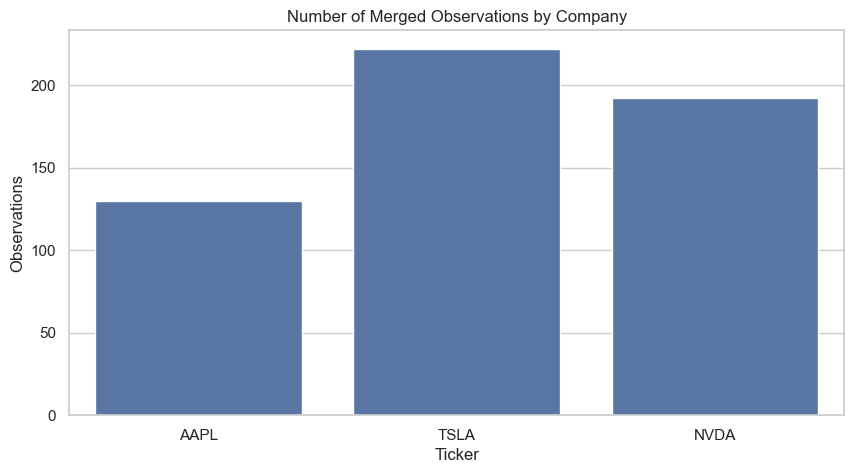

In [230]:
plt.figure(figsize=(10, 5))
sns.countplot(data=model_df, x="Ticker", order=selected_tickers)
plt.title("Number of Merged Observations by Company")
plt.xlabel("Ticker")
plt.ylabel("Observations")
plt.show()

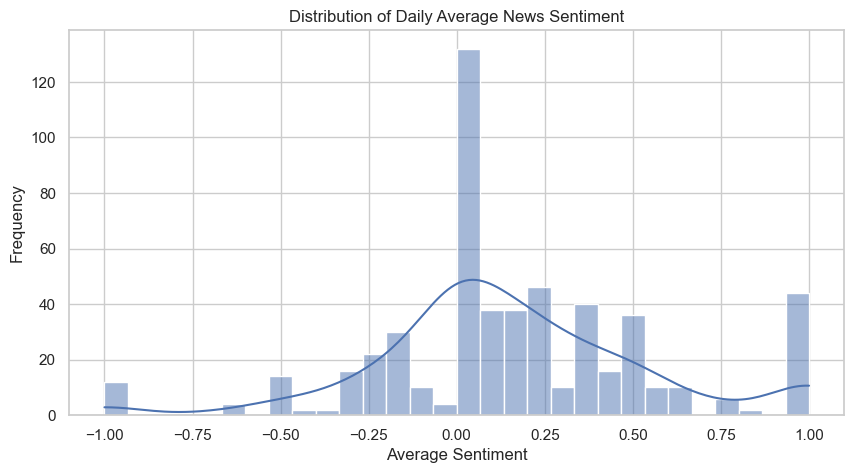

In [231]:
plt.figure(figsize=(10, 5))
sns.histplot(model_df["avg_sentiment"], bins=30, kde=True)
plt.title("Distribution of Daily Average News Sentiment")
plt.xlabel("Average Sentiment")
plt.ylabel("Frequency")
plt.show()

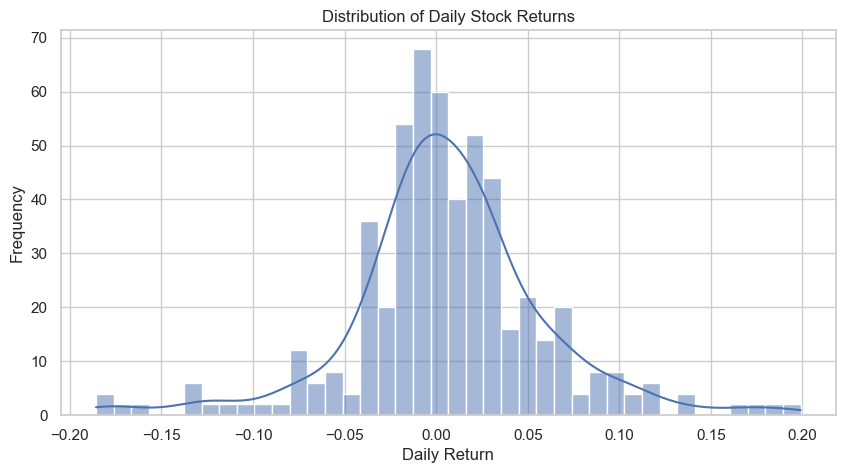

In [232]:
plt.figure(figsize=(10, 5))
sns.histplot(model_df["Daily Return"].dropna(), bins=40, kde=True)
plt.title("Distribution of Daily Stock Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

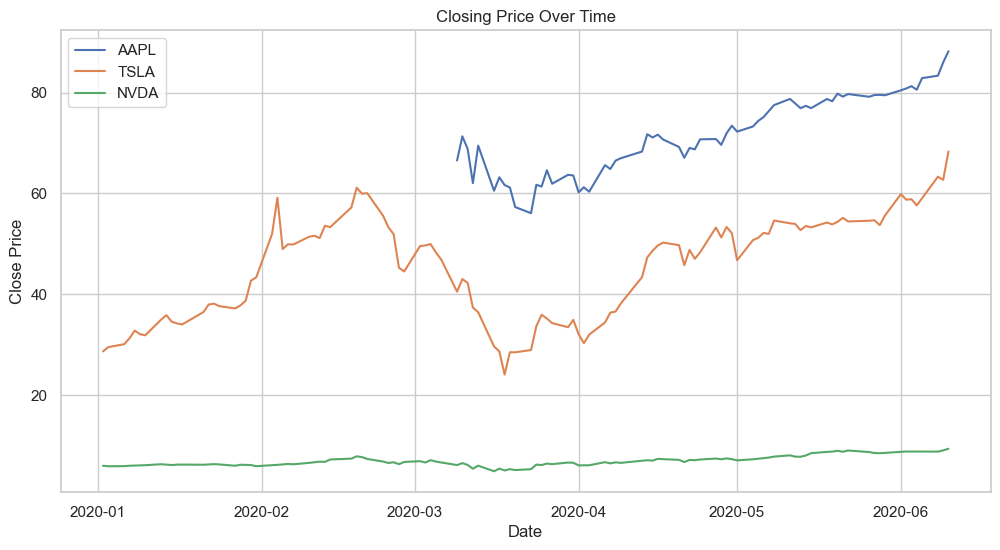

In [233]:
plt.figure(figsize=(12, 6))
for ticker in selected_tickers:
    subset = model_df[model_df["Ticker"] == ticker]
    plt.plot(subset["Date"], subset["Close"], label=ticker)

plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

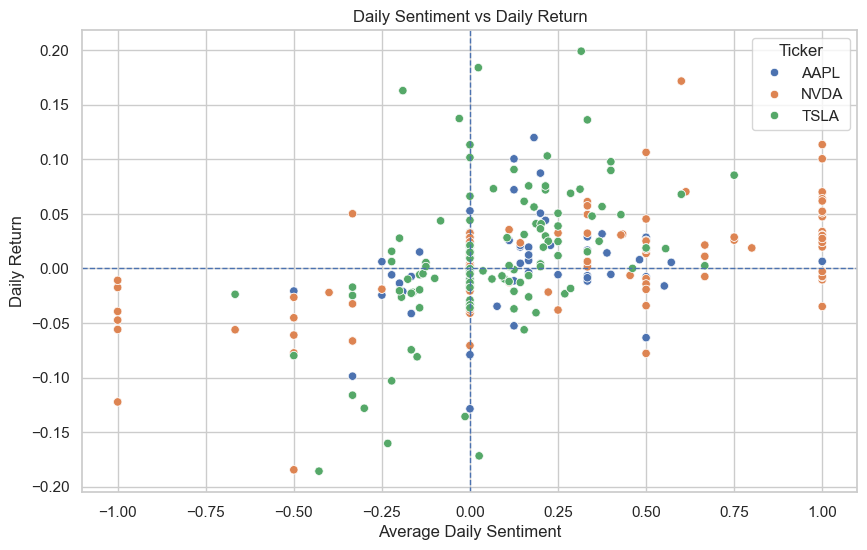

In [234]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=model_df,
    x="avg_sentiment",
    y="Daily Return",
    hue="Ticker"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Daily Sentiment vs Daily Return")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return")
plt.show()

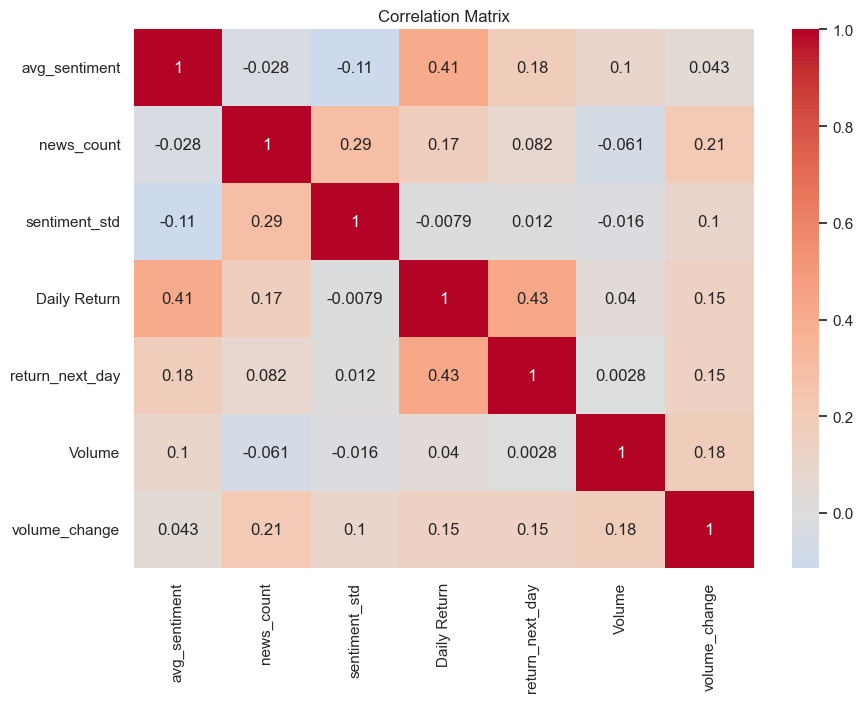

In [235]:
corr_columns = ["avg_sentiment", "news_count", "sentiment_std", "Daily Return", "return_next_day", "Volume", "volume_change"]
corr_columns = [column for column in corr_columns if column in model_df.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(model_df[corr_columns].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## 9. Hypothesis testing

### Hypothesis 1: correlation between sentiment and same-day returns

- $H_0$: There is no linear relationship between daily sentiment and same-day returns.
- $H_1$: There is a linear relationship between daily sentiment and same-day returns.

### Hypothesis 2: correlation between sentiment and next-day returns

- $H_0$: There is no linear relationship between daily sentiment and next-day returns.
- $H_1$: There is a linear relationship between daily sentiment and next-day returns.

In [236]:
def correlation_test(data, x_col, y_col):
    clean = data[[x_col, y_col]].dropna()
    if len(clean) < 3:
        return {
            "n": len(clean),
            "pearson_r": np.nan,
            "p_value": np.nan
        }

    r, p = stats.pearsonr(clean[x_col], clean[y_col])
    return {
        "n": len(clean),
        "pearson_r": r,
        "p_value": p
    }

results = []

for ticker in selected_tickers:
    subset = model_df[model_df["Ticker"] == ticker]

    same_day = correlation_test(subset, "avg_sentiment", "Daily Return")
    same_day["Ticker"] = ticker
    same_day["Target"] = "Same-day return"
    results.append(same_day)

    next_day = correlation_test(subset, "avg_sentiment", "return_next_day")
    next_day["Ticker"] = ticker
    next_day["Target"] = "Next-day return"
    results.append(next_day)

correlation_results = pd.DataFrame(results)
display(correlation_results)

,n,pearson_r,p_value,Ticker,Target
0,130,0.232177,7.858559e-03,AAPL,Same-day return
1,130,0.021904,8.046268e-01,AAPL,Next-day return
2,221,0.464928,2.985398e-13,TSLA,Same-day return
3,222,0.275182,3.217120e-05,TSLA,Next-day return
4,191,0.578991,1.731844e-18,NVDA,Same-day return
5,192,0.235977,9.838661e-04,NVDA,Next-day return


### T-test: returns on positive-sentiment days vs negative-sentiment days

The project also compares average returns on positive-sentiment days and negative-sentiment days.

- $H_0$: Mean returns are equal for positive and negative sentiment days.
- $H_1$: Mean returns are different for positive and negative sentiment days.

In [237]:
ttest_results = []

for ticker in selected_tickers:
    subset = model_df[model_df["Ticker"] == ticker].dropna(subset=["Daily Return", "avg_sentiment"])

    positive_returns = subset[subset["avg_sentiment"] > 0]["Daily Return"]
    negative_returns = subset[subset["avg_sentiment"] < 0]["Daily Return"]

    if len(positive_returns) >= 2 and len(negative_returns) >= 2:
        t_stat, p_value = stats.ttest_ind(
            positive_returns,
            negative_returns,
            equal_var=False
        )
    else:
        t_stat, p_value = np.nan, np.nan

    ttest_results.append({
        "Ticker": ticker,
        "Positive sentiment days": len(positive_returns),
        "Negative sentiment days": len(negative_returns),
        "Mean return positive": positive_returns.mean() if len(positive_returns) else np.nan,
        "Mean return negative": negative_returns.mean() if len(negative_returns) else np.nan,
        "t_statistic": t_stat,
        "p_value": p_value
    })

ttest_results_df = pd.DataFrame(ttest_results)
display(ttest_results_df)

,Ticker,Positive sentiment days,Negative sentiment days,Mean return positive,Mean return negative,t_statistic,p_value
0,AAPL,76,20,0.015285,-0.021242,4.551925,6.432052e-05
1,TSLA,115,62,0.030802,-0.029129,5.572696,2.084540e-07
2,NVDA,112,34,0.025382,-0.049107,8.015223,2.062123e-10


## 10. Predictive modeling

The target variable is **next-day daily return**.

Using next-day return reduces look-ahead bias compared to using same-day returns, because the goal is to test whether today's news sentiment helps predict the following trading day's return.

### Models

The project compares three models:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

### Evaluation metrics

The following metrics are used:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y_i})^2
$$

$$
RMSE = \sqrt{MSE}
$$

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y_i}|
$$

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

In [238]:
model_data = model_df.dropna(subset=["return_next_day", "avg_sentiment", "news_count", "Daily Return", "Volume"]).copy()

model_data["Ticker_encoded"] = model_data["Ticker"].astype("category").cat.codes

feature_columns = [
    "avg_sentiment",
    "news_count",
    "sentiment_std",
    "Daily Return",
    "Volume",
    "volume_change",
    "Ticker_encoded"
]

feature_columns = [column for column in feature_columns if column in model_data.columns]

model_data = model_data.replace([np.inf, -np.inf], np.nan)
model_data = model_data.dropna(subset=feature_columns + ["return_next_day"])

X = model_data[feature_columns]
y = model_data["return_next_day"]

print("Modeling dataset shape:", model_data.shape)
print("Features:", feature_columns)
display(model_data.head())

Modeling dataset shape: (542, 15)
Features: ['avg_sentiment', 'news_count', 'sentiment_std', 'Daily Return', 'Volume', 'volume_change', 'Ticker_encoded']


,Ticker,Date,Open,High,Low,Close,Volume,Daily Return,return_next_day,avg_sentiment,news_count,sentiment_std,20-Day MA,volume_change,Ticker_encoded
0,AAPL,2020-03-09,65.937500,69.522499,65.750000,66.542503,286744800,-0.079092,-0.079092,0.000000,3,0.000000,NaN,0.267791,0
1,AAPL,2020-03-09,65.937500,69.522499,65.750000,66.542503,286744800,-0.079092,0.072022,0.000000,3,0.000000,75.736624,0.000000,0
2,AAPL,2020-03-10,69.285004,71.610001,67.342499,71.334999,285290000,0.072022,0.072022,0.125000,8,0.640870,NaN,-0.005074,0
3,AAPL,2020-03-10,69.285004,71.610001,67.342499,71.334999,285290000,0.072022,-0.034731,0.125000,8,0.640870,75.283999,0.000000,0
4,AAPL,2020-03-11,69.347504,70.305000,67.964996,68.857498,255598800,-0.034731,-0.034731,0.076923,13,0.759555,NaN,-0.104074,0


## 11. Optional causality-oriented analysis

A full causality-driven financial prediction framework would require more advanced econometric validation, including stationarity testing, lag selection, and causal assumptions.

As a lightweight extension, this notebook checks whether lagged sentiment has predictive value by creating lag features.

In [239]:
lagged_df = model_df.sort_values(["Ticker", "Date"]).copy()

for lag in [1, 2, 3]:
    lagged_df[f"sentiment_lag_{lag}"] = lagged_df.groupby("Ticker")["avg_sentiment"].shift(lag)

lag_feature_columns = [
    "avg_sentiment",
    "sentiment_lag_1",
    "sentiment_lag_2",
    "sentiment_lag_3",
    "news_count",
    "Daily Return"
]

lag_model_data = lagged_df.dropna(subset=lag_feature_columns + ["return_next_day"]).copy()

if len(lag_model_data) >= 30:
    X_lag = lag_model_data[lag_feature_columns]
    y_lag = lag_model_data["return_next_day"]

    X_train_lag, X_test_lag, y_train_lag, y_test_lag = train_test_split(
        X_lag,
        y_lag,
        test_size=0.25,
        random_state=42
    )

    lag_model = LinearRegression()
    lag_model.fit(X_train_lag, y_train_lag)
    lag_predictions = lag_model.predict(X_test_lag)

    lag_results = {
        "MSE": mean_squared_error(y_test_lag, lag_predictions),
        "RMSE": math.sqrt(mean_squared_error(y_test_lag, lag_predictions)),
        "MAE": mean_absolute_error(y_test_lag, lag_predictions),
        "R2": r2_score(y_test_lag, lag_predictions)
    }

    print("Lagged sentiment linear model results:")
    display(pd.DataFrame([lag_results]))

    coefficients = pd.DataFrame({
        "Feature": lag_feature_columns,
        "Coefficient": lag_model.coef_
    })
    display(coefficients)
else:
    print("Not enough data for lagged sentiment modeling.")

Lagged sentiment linear model results:


,MSE,RMSE,MAE,R2
0,0.002851,0.053399,0.03478,0.109646


,Feature,Coefficient
0,avg_sentiment,0.022330
1,sentiment_lag_1,-0.039099
2,sentiment_lag_2,0.023977
3,sentiment_lag_3,-0.001255
4,news_count,0.000163
5,Daily Return,0.461642


## 12. Conclusion

We build a complete data analysis pipeline combining financial news and stock market data. The main contribution is transforming unstructured financial headlines into structured daily sentiment features and testing whether they are related to stock returns.

The project demonstrates:

- data consolidation from two independent sources
- text cleaning and sentiment feature engineering
- financial return calculation
- exploratory data analysis
- statistical hypothesis testing
- supervised regression modeling
- model evaluation using standard error metrics


## References

- Uploaded dataset: `analyst_ratings_processed.csv`
- Uploaded dataset: `tech_stock_prices_2020_to_today.csv`
- Python libraries: pandas, numpy, matplotlib, seaborn, scipy, scikit-learn
- Financial concepts: daily returns, Pearson correlation, regression, hypothesis testing